In [11]:
from typing import TypedDict, Dict, List
from langgraph.graph import StateGraph, END

import random

In [5]:
class AgentState(TypedDict):
    player_name: str
    guesses: List[int]
    attempts: int
    lower_bound: int
    upper_bound: int
    target_number: int
    hint: str

In [7]:
def setup_node(state: AgentState) -> AgentState:
    """This node does the initial setup"""

    state['player_name'] = f"Welcome, {state['player_name']}!"
    state['attempts'] = 0
    state['lower_bound'] = 1
    state['upper_bound'] = 20
    state['target_number'] = random.randint(1, 20)
    state['hint'] = "Guess the number!"

    print(f"{state['player_name']} The game has started, and I'm thinking of a number between 1 and 20")
    
    return state

In [8]:
def guess_node(state: AgentState) -> AgentState:
    """This node makes a guess on the number"""
    
    possible_guesses = [i for i in range(state['lower_bound'], state['upper_bound'] + 1) if i not in state['guesses']] # Making a smart guess by removing already guessed numbers

    if possible_guesses:
        guess = random.choice(possible_guesses)
    else:
        guess = random.randint(state['lower_bound'], state['upper_bound'])

    state['guesses'].append(guess)
    state['attempts'] += 1
    
    print(f"Attempt {state['attempts']}: Guessed Number {guess}")

    return state

In [9]:
def hint_node(state: AgentState) -> AgentState:
    latest_guess = state['guesses'][-1]
    
    if latest_guess < state['target_number']:
        state['hint'] = "Try higher!"

        state['lower_bound'] = max(state['lower_bound'], latest_guess + 1)
        
        print(f"Hint: {state['hint']}")
    
    elif latest_guess > state['target_number']:
        state['hint'] = "Try lower!"

        state['upper_bound'] = min(state['upper_bound'], latest_guess - 1)

        print(f"Hint: {state['hint']}")

    else:
        state['hint'] = f"Correct guess! You found the number {state['target_number']} in {state['attempts']} attempts."

        print(state['hint'])

    return state

In [10]:
def should_continue_node(state: AgentState) -> AgentState:
    latest_guess = state['guesses'][-1]

    if latest_guess == state['target_number']:
        print("Number Found!")

        return "exit"
    
    elif state['attempts'] >= 7:
        print(f"All attempts are exhausted. The number was {state['target_number']}")

        return "exit"
    
    else:
        print(f"Guessing: {state['attempts']}/7 attempts used")

        return "loop"

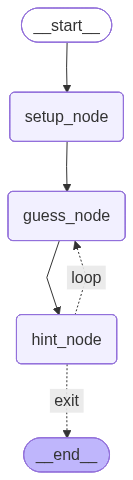

In [14]:
graph = StateGraph(AgentState)

graph.add_node("setup_node", setup_node)
graph.add_node("guess_node", guess_node)
graph.add_node("hint_node", hint_node)

graph.add_edge("setup_node", "guess_node")
graph.add_edge("guess_node", "hint_node")

graph.set_entry_point("setup_node")

graph.add_conditional_edges(
    "hint_node",
    should_continue_node,
    {
        "loop": "guess_node",
        "exit": END
    }
)

app = graph.compile()

app


In [15]:
initial_state = AgentState(player_name="Student", guesses=[], attempts=0, lower_bound=0, upper_bound=20)

app.invoke(initial_state)

Welcome, Student! The game has started, and I'm thinking of a number between 1 and 20
Attempt 1: Guessed Number 8
Hint: Try higher!
Guessing: 1/7 attempts used
Attempt 2: Guessed Number 19
Hint: Try lower!
Guessing: 2/7 attempts used
Attempt 3: Guessed Number 14
Hint: Try higher!
Guessing: 3/7 attempts used
Attempt 4: Guessed Number 18
Hint: Try lower!
Guessing: 4/7 attempts used
Attempt 5: Guessed Number 16
Hint: Try lower!
Guessing: 5/7 attempts used
Attempt 6: Guessed Number 15
Correct guess! You found the number 15 in 6 attempts.
Number Found!


{'player_name': 'Welcome, Student!',
 'guesses': [8, 19, 14, 18, 16, 15],
 'attempts': 6,
 'lower_bound': 15,
 'upper_bound': 15,
 'target_number': 15,
 'hint': 'Correct guess! You found the number 15 in 6 attempts.'}